ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.



In this lab, we will apply practical preprocessing techniques step by step.

In [50]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [72]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("social_media_productivity_6000.csv")
df.head(10)

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09
5,35.0,6.19,2.19,7.26,4.41,218.0,100.00,Medium,67.38
6,21.0,3.68,1.23,1.34,7.41,296.0,100.00,Low,37.22
7,33.0,10.79,5.65,0.08,7.95,148.0,83.64,High,0.00
8,37.0,7.57,5.54,0.59,8.81,81.0,94.43,High,0.00
9,25.0,4.31,2.73,1.79,4.74,21.0,100.00,Medium,41.86


## 2. Data Quality Assessment
### 2.1 Check Data Types

In [52]:
df.dtypes

,0
age,float64
daily_screen_time,float64
social_media_hours,float64
study_hours,float64
sleep_hours,float64
notifications_per_day,float64
focus_score,float64
addiction_level,object
productivity_score,float64


In [53]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


,0
age,float64
daily_screen_time,float64
social_media_hours,float64
study_hours,float64
sleep_hours,float64
notifications_per_day,float64
focus_score,float64
addiction_level,object
productivity_score,float64


There are no incorrect data types to be converted. Eight features are numerical (float64), while the categorical feature addiction_level is stored as object.


### 2.2 Check Duplicate Records

In [71]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [54]:
df.isna().sum()

,0
age,120
daily_screen_time,120
social_media_hours,120
study_hours,120
sleep_hours,120
notifications_per_day,120
focus_score,120
addiction_level,120
productivity_score,120


-Missing Values :
Each column contains 120 missing values.
Since the dataset has 6000 records, approximately 2% of the values are missing in each feature.

### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [55]:
df_removed = df.dropna()

print("Original shape:", df.shape)
print("After removing missing values:", df_removed.shape)

df_removed.isnull().sum()

Original shape: (6000, 9)
After removing missing values: (4999, 9)


,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
addiction_level,0
productivity_score,0


This strategy removes all rows that contain missing values using dropna(). After applying this method, the dataset size decreased from 6000 rows to 4999 rows, and all missing values were eliminated. While this approach produces a complete dataset, it may result in the loss of useful information because many records are discarded.

### Strategy 2: Mean Imputation



The mean represents the average value.
It is commonly used for normally distributed data.

In [56]:
df_mean = df.copy()

num_cols = df_mean.select_dtypes(include='number').columns

for col in num_cols:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

df_mean.isnull().sum()

,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
addiction_level,120
productivity_score,0


In [57]:
df_mean['addiction_level'] = df_mean['addiction_level'].fillna(
    df_mean['addiction_level'].mode()[0]
)
df_mean.isnull().sum()

,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
addiction_level,0
productivity_score,0


This strategy replaces missing numerical values with the mean (average) of each column. For the categorical feature addiction_level, the mode (most frequent category) was used. After applying mean imputation, all missing values were successfully removed while preserving the original dataset size. However, mean imputation can be sensitive to outliers and may reduce data variability.

### Strategy 3: Median Imputation

The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [58]:
df_median = df.copy()

num_cols = df_median.select_dtypes(include='number').columns

for col in num_cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

df_median['addiction_level'] = df_median['addiction_level'].fillna(
    df_median['addiction_level'].mode()[0]
)

df_median.isnull().sum()

,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
addiction_level,0
productivity_score,0


This strategy replaces missing numerical values with the median value of each column. For the categorical feature addiction_level, the mode was used. After applying median imputation, all missing values were removed while keeping all records in the dataset. Median imputation is generally more robust to outliers than mean imputation and is often preferred for skewed data distributions.

**Finally, Median imputation was selected as the final missing value strategy because it preserves all records and is more robust to outliers than mean imputation.**

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.



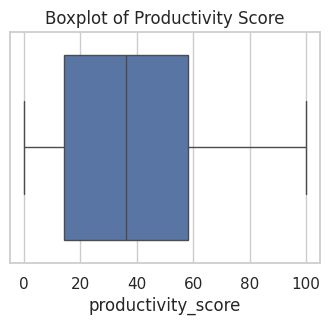

In [59]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df_median['productivity_score'])
plt.title("Boxplot of Productivity Score")
plt.show()

Points outside the whiskers represent potential outliers. These extreme productivity score values may influence data analysis and model performance.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [60]:
Q1 = df_median['productivity_score'].quantile(0.25)
Q3 = df_median['productivity_score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_median[
    (df_median['productivity_score'] < lower) |
    (df_median['productivity_score'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


The IQR method was applied to detect outliers in the productivity_score feature. No values were found outside the lower and upper IQR boundaries. Therefore, no outliers were detected and no records needed to be removed.

### Remove Outliers
We remove values outside the acceptable range.

In [61]:
df_no_outliers = df_median.copy()

print("Original shape:", df_median.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (6000, 9)
After removing outliers: (6000, 9)


Since no outliers were identified, removing outliers did not affect the dataset size, and all records were retained for further analysis.

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

In [62]:
lower_cap = df_median['productivity_score'].quantile(0.05)
upper_cap = df_median['productivity_score'].quantile(0.95)

df_capped = df_median.copy()

df_capped['productivity_score'] = df_capped[
    'productivity_score'
].clip(lower_cap, upper_cap)

df_capped.head(10)

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09
5,35.0,6.19,2.19,7.26,4.41,218.0,100.00,Medium,67.38
6,21.0,3.68,1.23,1.34,7.41,296.0,100.00,Low,37.22
7,33.0,10.79,5.65,0.08,7.95,148.0,83.64,High,0.00
8,37.0,7.57,5.54,0.59,8.81,81.0,94.43,High,0.00
9,25.0,4.31,2.73,1.79,4.74,21.0,100.00,Medium,41.86


The percentile capping method was applied to the productivity_score feature. Values below the 5th percentile were replaced with the lower cap, while values above the 95th percentile were replaced with the upper cap. This technique preserves all records in the dataset while reducing the influence of extreme values. The dataset size remained unchanged after applying capping.

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [63]:
numerical_cols = [
    'age',
    'daily_screen_time',
    'social_media_hours',
    'study_hours',
    'sleep_hours',
    'notifications_per_day',
    'focus_score',
    'productivity_score'
]

df_median[numerical_cols].head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,51.09


In [64]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = df_median.copy()

df_minmax[numerical_cols] = scaler.fit_transform(
    df_minmax[numerical_cols]
)

df_minmax[numerical_cols].head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
0,0.250000,0.395395,0.215,0.32625,0.598,0.942652,1.000000,0.2849
1,0.791667,0.182182,0.167,0.03500,0.694,0.881720,0.879301,0.1854
2,0.583333,0.157157,0.098,0.65125,0.468,0.419355,1.000000,0.6852
3,0.416667,0.827828,0.371,0.53500,0.098,0.813620,0.899449,0.2782
4,0.291667,0.042042,0.094,0.45875,0.468,0.028674,1.000000,0.5109


Min-Max normalization rescales numerical features to a range between 0 and 1. This ensures that all features have a similar scale and prevents features with larger values from dominating the analysis.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:



This method keeps the shape of the distribution but rescales it around zero.

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_zscore = df_median.copy()

df_zscore[numerical_cols] = scaler.fit_transform(
    df_zscore[numerical_cols]
)

df_zscore[numerical_cols].head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
0,-0.849111,-0.343420,-0.622248,-0.638755,0.334913,1.535890,0.484250,-0.332883
1,0.957754,-1.096046,-0.847140,-1.657969,0.672985,1.323981,-0.378604,-0.697029
2,0.262806,-1.184382,-1.170424,0.498566,-0.122893,-0.284030,0.484250,1.132118
3,-0.293152,1.183031,0.108653,0.091755,-1.425879,1.087142,-0.234568,-0.357403
4,-0.710121,-1.590729,-1.189165,-0.175078,-0.122893,-1.642737,0.484250,0.494222


Z-score normalization standardizes numerical features by centering them around zero and scaling them according to their standard deviation. This method is useful when features have different units or ranges.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful
because we can combine correlated features into fewer components.

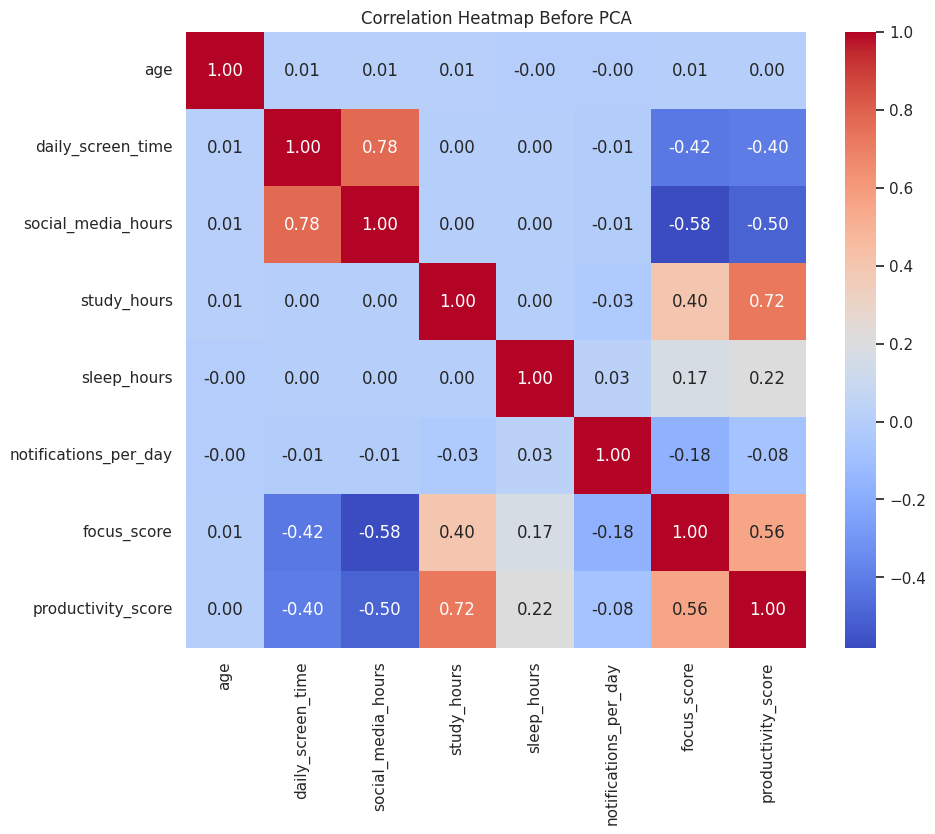

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'age',
    'daily_screen_time',
    'social_media_hours',
    'study_hours',
    'sleep_hours',
    'notifications_per_day',
    'focus_score',
    'productivity_score'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df_median[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap Before PCA')
plt.show()

The correlation heatmap shows the relationships between the numerical features in the dataset. Several features exhibit moderate to strong correlations. For example, daily_screen_time and social_media_hours have a strong positive correlation (0.78), indicating that users who spend more time on screens also tend to spend more time on social media. Additionally, study_hours and productivity_score show a strong positive correlation (0.72), suggesting that higher study time is associated with higher productivity. Some negative correlations are also observed, such as between social_media_hours and focus_score (-0.58), indicating that increased social media usage may be associated with lower focus levels.

Since several features are correlated, PCA can be useful for reducing dimensionality by combining overlapping information into a smaller number of principal components while retaining most of the dataset's variance.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

In [67]:
from sklearn.preprocessing import StandardScaler

numerical_cols = [
    'age',
    'daily_screen_time',
    'social_media_hours',
    'study_hours',
    'sleep_hours',
    'notifications_per_day',
    'focus_score',
    'productivity_score'
]

standard_scaler = StandardScaler()

df_standardized = df_median.copy()

df_standardized[numerical_cols] = standard_scaler.fit_transform(
    df_standardized[numerical_cols]
)

df_standardized.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,-0.849111,-0.343420,-0.622248,-0.638755,0.334913,1.535890,0.484250,Medium,-0.332883
1,0.957754,-1.096046,-0.847140,-1.657969,0.672985,1.323981,-0.378604,Medium,-0.697029
2,0.262806,-1.184382,-1.170424,0.498566,-0.122893,-0.284030,0.484250,Low,1.132118
3,-0.293152,1.183031,0.108653,0.091755,-1.425879,1.087142,-0.234568,Medium,-0.357403
4,-0.710121,-1.590729,-1.189165,-0.175078,-0.122893,-1.642737,0.484250,Low,0.494222


Z-score standardization was applied to all numerical features using the StandardScaler technique. This transformation rescales the data so that each feature has a mean of approximately 0 and a standard deviation of 1. Standardization helps ensure that features with larger numerical ranges do not dominate the analysis. As shown in the table, the numerical values are centered around zero, with positive values indicating observations above the mean and negative values indicating observations below the mean. This preprocessing step is particularly important before applying PCA because PCA is sensitive to feature scales.

In [68]:
from sklearn.decomposition import PCA

X = df_standardized[
    ['age',
     'daily_screen_time',
     'social_media_hours',
     'study_hours',
     'sleep_hours',
     'notifications_per_day',
     'focus_score',
     'productivity_score']
]

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.35328526 0.17620031]


Since the first two principal components capture approximately 52.95% of the total variance, they preserve a significant portion of the information contained in the original features. Although some information is lost, the reduced representation simplifies the dataset and makes visualization and analysis easier.

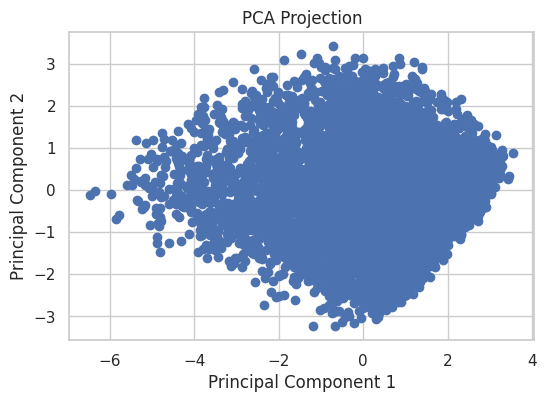

In [69]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The PCA projection visualizes the dataset using the first two principal components. Each point represents one record in the dataset. The horizontal axis corresponds to Principal Component 1 (PC1), while the vertical axis corresponds to Principal Component 2 (PC2). These components summarize the information contained in the original numerical features. The spread of the points indicates the variation captured by the principal components, allowing the dataset to be visualized in a lower-dimensional space.

#Dataset after cleaning


In [73]:
df_median.to_csv("social_media_productivity_cleaned.csv", index=False)